## Importation

In [1]:
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score, auc,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from torch_geometric.data import HeteroData
from torch_geometric.nn import RGCNConv

import optuna

/home/yona/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Graph Preparation 

In [2]:
with open('/media/Data/Yona/WSI CCRCC/embeddings_train.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open('/media/Data/Yona/WSI CCRCC/embeddings_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train = np.array(train_data['embeddings'])
pids_train = np.array(train_data['patient_ids'])
X_test  = np.array(test_data['embeddings'])
pids_test  = np.array(test_data['patient_ids'])

X_all   = np.concatenate([X_train, X_test], axis=0)
pids_all = np.concatenate([pids_train, pids_test], axis=0)
unique_pids = np.unique(pids_all)
pid_to_idx = {pid: i for i, pid in enumerate(unique_pids)}

# 2. Initialize HeteroData
data = HeteroData()

# Image node features
data['image'].x = torch.tensor(X_all, dtype=torch.float)

# Temporary patient node feature placeholder
data['patient'].x = torch.zeros((len(unique_pids), 1), dtype=torch.float)

# 3. Build image→patient edges
src_img, dst_pat = [], []
for img_idx, pid in enumerate(pids_all):
    src_img.append(img_idx)
    dst_pat.append(pid_to_idx[pid])
edge_index_ip = torch.tensor([src_img, dst_pat], dtype=torch.long)
data['image', 'to', 'patient'].edge_index = edge_index_ip

# 4. Add inverse patient→image edges
edge_index_pi = edge_index_ip.flip(0)  # swap rows to reverse direction
data['patient', 'rev', 'image'].edge_index = edge_index_pi

# 5. Load clinical/genomic features
df = pd.read_csv('/media/Data/Yona/WSI CCRCC/tables/clinical+genomic_split.csv', index_col='case_id')
df['age_diag'] = df['age_diag'].fillna(df['age_diag'].mean())
df['cancer_history'] = df['cancer_history'].fillna(0)
feat_cols = [c for c in df.columns if c not in ['vital_status_12', 'Split']]
df_feat = df.loc[unique_pids, feat_cols]

# Assign patient node features
data['patient'].x = torch.tensor(df_feat.values, dtype=torch.float)

# 6. Add clinical similarity edges (patients sharing cancer_history status)
src_clin, dst_clin = [], []
ch = df_feat['cancer_history'].values
for i in range(len(unique_pids)):
    for j in range(len(unique_pids)):
        if i != j and ch[i] == ch[j]:
            src_clin.append(i)
            dst_clin.append(j)
edge_index_pp = torch.tensor([src_clin, dst_clin], dtype=torch.long)
data['patient', 'clin', 'patient'].edge_index = edge_index_pp

# 7. Labels and masks
labels = df.loc[unique_pids, 'vital_status_12'].astype(int).values
splits = df.loc[unique_pids, 'Split'].values
data['patient'].y = torch.tensor(labels, dtype=torch.long)
data['patient'].train_mask = torch.tensor(splits == 'train')
data['patient'].val_mask   = torch.tensor(splits == 'validation')
data['patient'].test_mask  = torch.tensor(splits == 'test')

# 8. Summary prints
print(f"Image nodes:   {data['image'].num_nodes}")
print(f"Patient nodes: {data['patient'].num_nodes}")
print(f"Edges image→patient: {data['image','to','patient'].edge_index.size(1)}")
print(f"Edges patient→image: {data['patient','rev','image'].edge_index.size(1)}")
print(f"Clinical edges patient→patient: {data['patient','clin','patient'].edge_index.size(1)}")
print(f"Patient feature shape: {data['patient'].x.shape}")
print(f"Label distribution: train={data['patient'].train_mask.sum().item()}, "
      f"val={data['patient'].val_mask.sum().item()}, "
      f"test={data['patient'].test_mask.sum().item()}")


Image nodes:   2134
Patient nodes: 617
Edges image→patient: 2134
Edges patient→image: 2134
Clinical edges patient→patient: 300648
Patient feature shape: torch.Size([617, 17])
Label distribution: train=479, val=18, test=120


## Grid search 

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        pt = probs.gather(1, target.view(-1, 1)).squeeze(1)
        log_pt = log_probs.gather(1, target.view(-1, 1)).squeeze(1)

        loss = -((1.0 - pt) ** self.gamma) * log_pt

        if self.alpha is not None:
            at = self.alpha.gather(0, target)
            loss = loss * at

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

# Model (RGCN) + residual/skip connections
class RelationalGNN(nn.Module):
    def __init__(
        self,
        in_img,
        in_pat,
        hidden_dim,
        dropout_gnn,
        dropout_mlp,
        num_classes,
        num_relations,
        num_layers,
        use_residual,
    ):
        super().__init__()
        self.use_residual = use_residual

        self.lin_img = nn.Linear(in_img, hidden_dim)
        self.lin_pat = nn.Linear(in_pat, hidden_dim)

        self.convs = nn.ModuleList(
            [RGCNConv(hidden_dim, hidden_dim, num_relations) for _ in range(num_layers)]
        )

        self.drop_gnn = nn.Dropout(dropout_gnn)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_mlp),
        )

        self.out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_img, x_pat, edge_index, edge_type):
        h_img = F.gelu(self.lin_img(x_img))
        h_pat = F.gelu(self.lin_pat(x_pat))
        h = torch.cat([h_img, h_pat], dim=0)

        for conv in self.convs:
            h_prev = h
            h = F.gelu(conv(h, edge_index, edge_type))
            h = self.drop_gnn(h)
            if self.use_residual:
                h = h + h_prev

        h = self.mlp(h)
        return self.out(h)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

data = data.to(device)

x_img = data["image"].x.to(device)
x_pat_full = data["patient"].x.to(device)
y_pat = data["patient"].y.to(device)

train_mask = data["patient"].train_mask.to(device)
val_mask   = data["patient"].val_mask.to(device)
test_mask  = data["patient"].test_mask.to(device)

N_img = data["image"].num_nodes
N_pat = data["patient"].num_nodes

in_img = x_img.shape[1]
in_pat = x_pat_full.shape[1]
num_classes = 2


# Fixed edges: image <-> patient relations (types 0 and 1)
def build_fixed_ip_edges():
    edge_indices = []
    edge_types = []

    ei = data["image", "to", "patient"].edge_index.to(device)
    edge_indices.append(torch.vstack([ei[0], ei[1] + N_img]))
    edge_types.append(torch.zeros(ei.size(1), dtype=torch.long, device=device))

    ei = data["patient", "rev", "image"].edge_index.to(device)
    edge_indices.append(torch.vstack([ei[0] + N_img, ei[1]]))
    edge_types.append(torch.ones(ei.size(1), dtype=torch.long, device=device))

    return edge_indices, edge_types

fixed_edge_indices, fixed_edge_types = build_fixed_ip_edges()


def resolve_knn_feature_indices(knn_feature_set, df_feat_columns):
    cols = list(df_feat_columns)

    if knn_feature_set == "all_features":
        return np.arange(len(cols), dtype=np.int64)

    clinical_like = []
    genomic_like = []
    for i, c in enumerate(cols):
        lc = c.lower()
        if ("mutation" in lc) or ("gene" in lc) or ("cnv" in lc) or ("rna" in lc) or ("expr" in lc):
            genomic_like.append(i)
        else:
            clinical_like.append(i)

    if knn_feature_set == "clinical_only":
        return np.array(clinical_like, dtype=np.int64) if clinical_like else np.arange(len(cols), dtype=np.int64)

    if knn_feature_set == "genomic_only":
        return np.array(genomic_like, dtype=np.int64) if genomic_like else np.arange(len(cols), dtype=np.int64)

    if knn_feature_set == "mixed_small":
        idx = clinical_like[:10] + genomic_like[:10]
        return np.array(idx, dtype=np.int64) if idx else np.arange(len(cols), dtype=np.int64)

    return np.arange(len(cols), dtype=np.int64)

# kNN patient-patient edges (TRAIN-ONLY fit per fold)
def build_knn_patient_edges_fold(
    x_pat_knn_cpu,
    train_pat_idx,
    k,
    metric="cosine",
    symmetric=True,
    use_scaler=True,
):
    train_pat_idx = np.array(train_pat_idx, dtype=np.int64)
    X = x_pat_knn_cpu.astype(np.float32)

    if use_scaler:
        scaler = StandardScaler()
        scaler.fit(X[train_pat_idx])
        X = scaler.transform(X).astype(np.float32)

    if metric not in ("cosine", "euclidean"):
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    nn_model = NearestNeighbors(n_neighbors=min(k, len(train_pat_idx)), metric=metric)
    nn_model.fit(X[train_pat_idx])
    _, nn_pos = nn_model.kneighbors(X)

    src, dst = [], []
    for i in range(N_pat):
        neigh = train_pat_idx[nn_pos[i]].tolist()
        if i in neigh:
            neigh.remove(i)
        neigh = neigh[:k]
        for j in neigh:
            src.append(i)
            dst.append(j)

    if symmetric:
        src_rev, dst_rev = dst, src
        src = src + src_rev
        dst = dst + dst_rev

    src = torch.tensor(src, dtype=torch.long, device=device)
    dst = torch.tensor(dst, dtype=torch.long, device=device)

    edge_index_pp = torch.vstack([src + N_img, dst + N_img])
    edge_type_pp = torch.full((edge_index_pp.size(1),), 2, dtype=torch.long, device=device)

    return edge_index_pp, edge_type_pp

# Focal alpha from fold-train only
def focal_alpha_from_indices(y_pat, train_indices):
    y_tr = y_pat[train_indices].detach().cpu().numpy()
    n0 = int((y_tr == 0).sum())
    n1 = int((y_tr == 1).sum())
    n = n0 + n1
    a0 = n / (2 * max(n0, 1))
    a1 = n / (2 * max(n1, 1))
    return torch.tensor([a0, a1], dtype=torch.float, device=device)

def make_global_patient_mask(pat_indices):
    m_pat = torch.zeros(N_pat, dtype=torch.bool, device=device)
    m_pat[torch.tensor(pat_indices, dtype=torch.long, device=device)] = True
    m_global = torch.cat([torch.zeros(N_img, dtype=torch.bool, device=device), m_pat])
    return m_global, m_pat

def warmup_lr_factor(epoch, warmup_epochs):
    if warmup_epochs <= 0 or epoch >= warmup_epochs:
        return 1.0
    return float(epoch + 1) / float(warmup_epochs)

# Prepare CV indices (train + val) used for Optuna
tv_mask = (train_mask | val_mask).detach().cpu().numpy().astype(bool)
test_idx = np.where(test_mask.detach().cpu().numpy().astype(bool))[0]

tv_idx = np.where(tv_mask)[0]
y_tv = y_pat.detach().cpu().numpy()[tv_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

x_pat_full_cpu = x_pat_full.detach().cpu().numpy()
try:
    df_feat_columns = df_feat.columns
except Exception:
    df_feat_columns = [f"f{i}" for i in range(x_pat_full_cpu.shape[1])]

# Optuna objective
def objective(trial: optuna.Trial) -> float:
    set_seed(42)

    hidden_dim = trial.suggest_categorical("hidden_dim", [16, 32, 48, 64, 80, 96, 128])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    use_residual = trial.suggest_categorical("use_residual", [True, False])

    dropout_gnn = trial.suggest_float("dropout_gnn", 0.0, 0.6, step=0.1)
    dropout_mlp = trial.suggest_float("dropout_mlp", 0.0, 0.6, step=0.1)

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    num_epochs = trial.suggest_int("num_epochs", 30, 150, step=15)

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128, 256])
    warmup_epochs = trial.suggest_int("warmup_epochs", 0, 20, step=5)
    grad_clip = trial.suggest_categorical("grad_clip", [0.0, 0.5, 1.0, 2.0, 5.0])

    knn_feature_set = trial.suggest_categorical(
        "knn_feature_set",
        ["all_features", "clinical_only", "genomic_only", "mixed_small"]
    )
    k_neighbors = trial.suggest_int("k_neighbors", 3, 40, step=1)
    knn_metric = trial.suggest_categorical("knn_metric", ["cosine", "euclidean"])
    knn_sym = trial.suggest_categorical("knn_symmetric", [True, False])
    knn_use_scaler = trial.suggest_categorical("knn_use_scaler", [True, False])
    gamma = trial.suggest_float("focal_gamma", 0.5, 5.0, step=0.5)

    feat_idx = resolve_knn_feature_indices(knn_feature_set, df_feat_columns)
    x_pat_knn_cpu = x_pat_full_cpu[:, feat_idx]

    fold_scores = []

    for fold_id, (tr_pos, va_pos) in enumerate(skf.split(tv_idx, y_tv), start=1):
        train_pat_idx = tv_idx[tr_pos]
        val_pat_idx = tv_idx[va_pos]

        mask_train_global, mask_train_pat = make_global_patient_mask(train_pat_idx)
        mask_val_global, mask_val_pat = make_global_patient_mask(val_pat_idx)

        edge_index_pp, edge_type_pp = build_knn_patient_edges_fold(
            x_pat_knn_cpu=x_pat_knn_cpu,
            train_pat_idx=train_pat_idx,
            k=k_neighbors,
            metric=knn_metric,
            symmetric=knn_sym,
            use_scaler=knn_use_scaler,
        )

        edge_index = torch.cat([*fixed_edge_indices, edge_index_pp], dim=1)
        edge_type = torch.cat([*fixed_edge_types, edge_type_pp], dim=0)

        model = RelationalGNN(
            in_img=in_img,
            in_pat=in_pat,
            hidden_dim=hidden_dim,
            dropout_gnn=dropout_gnn,
            dropout_mlp=dropout_mlp,
            num_classes=num_classes,
            num_relations=3,
            num_layers=num_layers,
            use_residual=use_residual,
        ).to(device)

        alpha = focal_alpha_from_indices(y_pat, train_pat_idx)
        loss_fn = FocalLoss(gamma=gamma, alpha=alpha, reduction="mean")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        train_pat_idx_list = train_pat_idx.tolist()
        n_train = len(train_pat_idx_list)

        for epoch in range(num_epochs):
            model.train()

            lr_factor = warmup_lr_factor(epoch, warmup_epochs)
            for pg in optimizer.param_groups:
                pg["lr"] = lr * lr_factor

            rng = np.random.default_rng(42 + epoch + fold_id)
            rng.shuffle(train_pat_idx_list)

            for start in range(0, n_train, batch_size):
                batch_pat = train_pat_idx_list[start:start + batch_size]

                optimizer.zero_grad()
                out = model(x_img, x_pat_full, edge_index, edge_type)
                batch_global_mask, batch_pat_mask = make_global_patient_mask(batch_pat)
                loss = loss_fn(out[batch_global_mask], y_pat[batch_pat_mask])
                loss.backward()

                if grad_clip and grad_clip > 0.0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

                optimizer.step()

            if (epoch + 1) % 10 == 0:
                model.eval()
                with torch.no_grad():
                    out = model(x_img, x_pat_full, edge_index, edge_type)
                    prob_pos = torch.softmax(out[mask_val_global], dim=1)[:, 1].cpu().numpy()
                    y_true = y_pat[mask_val_pat].cpu().numpy()

                    try:
                        score = roc_auc_score(y_true, prob_pos)
                    except Exception:
                        score = balanced_accuracy_score(y_true, (prob_pos >= 0.5).astype(int))

                approx_mean = float(np.mean(fold_scores + [score]))
                trial.report(approx_mean, step=(fold_id * 1000 + (epoch + 1)))
                if trial.should_prune():
                    raise optuna.TrialPruned()

        model.eval()
        with torch.no_grad():
            out = model(x_img, x_pat_full, edge_index, edge_type)
            prob_pos = torch.softmax(out[mask_val_global], dim=1)[:, 1].cpu().numpy()
            y_true = y_pat[mask_val_pat].cpu().numpy()

        try:
            fold_score = roc_auc_score(y_true, prob_pos)
        except Exception:
            fold_score = balanced_accuracy_score(y_true, (prob_pos >= 0.5).astype(int))

        fold_scores.append(float(fold_score))

    return float(np.mean(fold_scores))

# Run Optuna
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nBest mean CV ROC-AUC:", study.best_value)
print("Best params:", study.best_params)

try:
    best_per_set = {}
    for t in study.trials:
        if t.value is None:
            continue
        s = t.params.get("knn_feature_set", "all_features")
        best_per_set[s] = max(best_per_set.get(s, -1e9), t.value)
    print("\nBest CV score per knn_feature_set:")
    for k, v in sorted(best_per_set.items(), key=lambda x: -x[1]):
        print(k, ":", v)
except Exception:
    pass


# Final training on (train + val) using best params
best = study.best_params
set_seed(42)

tv_idx = np.where(tv_mask)[0]
train_final_idx = tv_idx
test_idx = np.where(test_mask.detach().cpu().numpy().astype(bool))[0]

mask_train_global_final, mask_train_pat_final = make_global_patient_mask(train_final_idx)
mask_test_global, mask_test_pat = make_global_patient_mask(test_idx)

feat_idx = resolve_knn_feature_indices(best.get("knn_feature_set", "all_features"), df_feat_columns)
x_pat_knn_cpu = x_pat_full_cpu[:, feat_idx]

edge_index_pp, edge_type_pp = build_knn_patient_edges_fold(
    x_pat_knn_cpu=x_pat_knn_cpu,
    train_pat_idx=train_final_idx,
    k=best["k_neighbors"],
    metric=best["knn_metric"],
    symmetric=best["knn_symmetric"],
    use_scaler=best["knn_use_scaler"],
)

edge_index_best = torch.cat([*fixed_edge_indices, edge_index_pp], dim=1)
edge_type_best = torch.cat([*fixed_edge_types, edge_type_pp], dim=0)

best_model = RelationalGNN(
    in_img=in_img,
    in_pat=in_pat,
    hidden_dim=best["hidden_dim"],
    dropout_gnn=best["dropout_gnn"],
    dropout_mlp=best["dropout_mlp"],
    num_classes=num_classes,
    num_relations=3,
    num_layers=best["num_layers"],
    use_residual=best["use_residual"],
).to(device)

alpha = focal_alpha_from_indices(y_pat, train_final_idx)
loss_fn = FocalLoss(gamma=best["focal_gamma"], alpha=alpha, reduction="mean")

optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=best["lr"],
    weight_decay=best["weight_decay"],
)

num_epochs = best["num_epochs"]
batch_size = best["batch_size"]
warmup_epochs = best["warmup_epochs"]
grad_clip = best["grad_clip"]

train_pat_idx_list = train_final_idx.tolist()
n_train = len(train_pat_idx_list)

for epoch in range(num_epochs):
    best_model.train()

    lr_factor = warmup_lr_factor(epoch, warmup_epochs)
    for pg in optimizer.param_groups:
        pg["lr"] = best["lr"] * lr_factor

    rng = np.random.default_rng(12345 + epoch)
    rng.shuffle(train_pat_idx_list)

    for start in range(0, n_train, batch_size):
        batch_pat = train_pat_idx_list[start:start + batch_size]

        optimizer.zero_grad()
        out = best_model(x_img, x_pat_full, edge_index_best, edge_type_best)
        batch_global_mask, batch_pat_mask = make_global_patient_mask(batch_pat)
        loss = loss_fn(out[batch_global_mask], y_pat[batch_pat_mask])
        loss.backward()

        if grad_clip and grad_clip > 0.0:
            torch.nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=grad_clip)

        optimizer.step()

print("\nFinal model trained on (train+val). Threshold tuning done in next cell.")

best_model.eval()
with torch.no_grad():
    out = best_model(x_img, x_pat_full, edge_index_best, edge_type_best)
    prob_test = torch.softmax(out[mask_test_global], dim=1)[:, 1].cpu().numpy()
    y_test = y_pat[mask_test_pat].cpu().numpy()

test_auc = roc_auc_score(y_test, prob_test) if len(np.unique(y_test)) > 1 else float("nan")
print(f"\n=== TEST ROC-AUC (no threshold): {test_auc:.4f} ===")

Using device: cuda


[I 2026-06-08 17:49:25,786] A new study created in memory with name: no-name-80ed6532-bd40-42b2-9bf6-eac5ae09eb24
Best trial: 0. Best value: 0.5:   2%|▏         | 1/50 [00:36<29:43, 36.40s/it]

[I 2026-06-08 17:50:02,182] Trial 0 finished with value: 0.5 and parameters: {'hidden_dim': 32, 'num_layers': 3, 'use_residual': False, 'dropout_gnn': 0.0, 'dropout_mlp': 0.6, 'lr': 0.002595942550311264, 'weight_decay': 1.879466824163843e-07, 'num_epochs': 45, 'batch_size': 64, 'warmup_epochs': 15, 'grad_clip': 5.0, 'knn_feature_set': 'genomic_only', 'k_neighbors': 26, 'knn_metric': 'cosine', 'knn_symmetric': False, 'knn_use_scaler': True, 'focal_gamma': 0.5}. Best is trial 0 with value: 0.5.


Best trial: 1. Best value: 0.82368:   4%|▍         | 2/50 [02:13<57:50, 72.29s/it]

[I 2026-06-08 17:51:39,602] Trial 1 finished with value: 0.8236795858269211 and parameters: {'hidden_dim': 96, 'num_layers': 2, 'use_residual': False, 'dropout_gnn': 0.30000000000000004, 'dropout_mlp': 0.1, 'lr': 0.004439102767051397, 'weight_decay': 0.0004475040191350909, 'num_epochs': 150, 'batch_size': 64, 'warmup_epochs': 0, 'grad_clip': 2.0, 'knn_feature_set': 'mixed_small', 'k_neighbors': 5, 'knn_metric': 'cosine', 'knn_symmetric': True, 'knn_use_scaler': True, 'focal_gamma': 4.0}. Best is trial 1 with value: 0.8236795858269211.


...

[I 2026-06-08 18:16:11,021] Trial 47 pruned. 


Best trial: 11. Best value: 0.85326:  98%|█████████▊| 49/50 [26:57<00:11, 11.94s/it]

[I 2026-06-08 18:16:23,314] Trial 48 pruned. 


Best trial: 11. Best value: 0.85326: 100%|██████████| 50/50 [27:01<00:00, 32.42s/it]


[I 2026-06-08 18:16:26,892] Trial 49 pruned. 

Best mean CV ROC-AUC: 0.8532604651530985
Best params: {'hidden_dim': 128, 'num_layers': 2, 'use_residual': True, 'dropout_gnn': 0.6, 'dropout_mlp': 0.6, 'lr': 0.0010834234325942517, 'weight_decay': 3.5378776459531286e-06, 'num_epochs': 120, 'batch_size': 128, 'warmup_epochs': 0, 'grad_clip': 1.0, 'knn_feature_set': 'clinical_only', 'k_neighbors': 38, 'knn_metric': 'euclidean', 'knn_symmetric': True, 'knn_use_scaler': True, 'focal_gamma': 3.5}

Best CV score per knn_feature_set:
clinical_only : 0.921875
genomic_only : 0.9043560606060606
mixed_small : 0.8598484848484848
all_features : 0.8329353487856623

Final model trained on (train+val). Threshold tuning done in next cell.

=== TEST ROC-AUC (no threshold): 0.8317 ===


In [4]:
best_model.eval()

tv_mask_np = (train_mask | val_mask).detach().cpu().numpy().astype(bool)
test_mask_np = test_mask.detach().cpu().numpy().astype(bool)

tv_idx = np.where(tv_mask_np)[0]
test_idx = np.where(test_mask_np)[0]

mask_tv_global, mask_tv_pat = make_global_patient_mask(tv_idx)
mask_test_global, mask_test_pat = make_global_patient_mask(test_idx)

with torch.no_grad():
    out = best_model(x_img, x_pat_full, edge_index_best, edge_type_best)

    # Train+Val probabilities
    logits_tv = out[mask_tv_global]
    prob_tv = torch.softmax(logits_tv, dim=1)[:, 1].detach().cpu().numpy()
    y_tv = y_pat[mask_tv_pat].detach().cpu().numpy()

    # Test probabilities
    logits_test = out[mask_test_global]
    prob_test = torch.softmax(logits_test, dim=1)[:, 1].detach().cpu().numpy()
    y_test = y_pat[mask_test_pat].detach().cpu().numpy()

# Sweep thresholds and pick the one maximizing BACC on Train+Val
thresholds = np.linspace(0.01, 0.99, 99)

best_thr = 0.5
best_bacc = -1.0
best_acc = -1.0

for thr in thresholds:
    pred_tv = (prob_tv >= thr).astype(int)
    bacc = balanced_accuracy_score(y_tv, pred_tv)
    acc = accuracy_score(y_tv, pred_tv)
    if bacc > best_bacc:
        best_bacc = bacc
        best_acc = acc
        best_thr = float(thr)

print("=== THRESHOLD TUNING (Train+Val) ===")
print(f"Best threshold: {best_thr:.2f}")
print(f"Train+Val BACC at best threshold: {best_bacc:.4f}")
print(f"Train+Val ACC  at best threshold: {best_acc:.4f}")

# Apply chosen threshold to TEST (fixed threshold, no tuning on test)
pred_test = (prob_test >= best_thr).astype(int)
test_bacc = balanced_accuracy_score(y_test, pred_test)
test_acc = accuracy_score(y_test, pred_test)

print("\n=== TEST RESULTS (Using tuned threshold) ===")
print(f"TEST BACC: {test_bacc:.4f}")
print(f"TEST ACC : {test_acc:.4f}")

cm = confusion_matrix(y_test, pred_test)
print("\nConfusion Matrix (Counts):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, pred_test, target_names=["Non-survival (0)", "Survival (1)"]))


=== THRESHOLD TUNING (Train+Val) ===
Best threshold: 0.51
Train+Val BACC at best threshold: 0.9641
Train+Val ACC  at best threshold: 0.9497

=== TEST RESULTS (Using tuned threshold) ===
TEST BACC: 0.7500
TEST ACC : 0.8417

Confusion Matrix (Counts):
[[10  6]
 [13 91]]

Classification Report:
                  precision    recall  f1-score   support

Non-survival (0)       0.43      0.62      0.51        16
    Survival (1)       0.94      0.88      0.91       104

        accuracy                           0.84       120
       macro avg       0.69      0.75      0.71       120
    weighted avg       0.87      0.84      0.85       120



# Final model

Using device: cuda
Training FINAL model on (train+val), monitoring train vs val
Config: {'hidden_dim': 128, 'num_layers': 2, 'dropout_p': 0.1, 'lr': 0.0005013165451552093, 'weight_decay': 3.8275975620529385e-06, 'num_epochs': 170, 'k_neighbors': 20, 'knn_metric': 'cosine', 'knn_symmetric': True, 'focal_gamma': 5.0}
Calibrated threshold used for monitoring/test: 0.484970
Epoch 001/170 | train_loss=0.0297 train_acc=0.5825 train_bacc=0.3782 | val_loss=0.0590 val_acc=0.5000 val_bacc=0.5000
Epoch 010/170 | train_loss=0.0181 train_acc=0.8372 train_bacc=0.7059 | val_loss=0.0486 val_acc=0.7778 val_bacc=0.7778
Epoch 020/170 | train_loss=0.0160 train_acc=0.7933 train_bacc=0.7698 | val_loss=0.0333 val_acc=0.6667 val_bacc=0.6667
Epoch 030/170 | train_loss=0.0147 train_acc=0.7996 train_bacc=0.7909 | val_loss=0.0262 val_acc=0.7778 val_bacc=0.7778
Epoch 040/170 | train_loss=0.0135 train_acc=0.8518 train_bacc=0.7936 | val_loss=0.0215 val_acc=0.8889 val_bacc=0.8889
Epoch 050/170 | train_loss=0.0120 tra

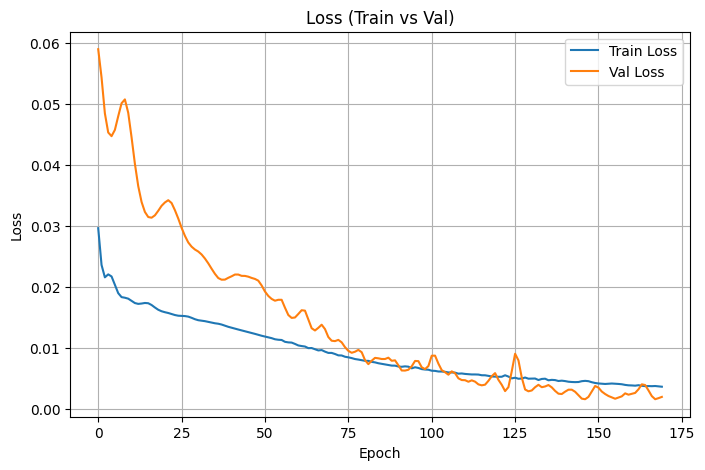

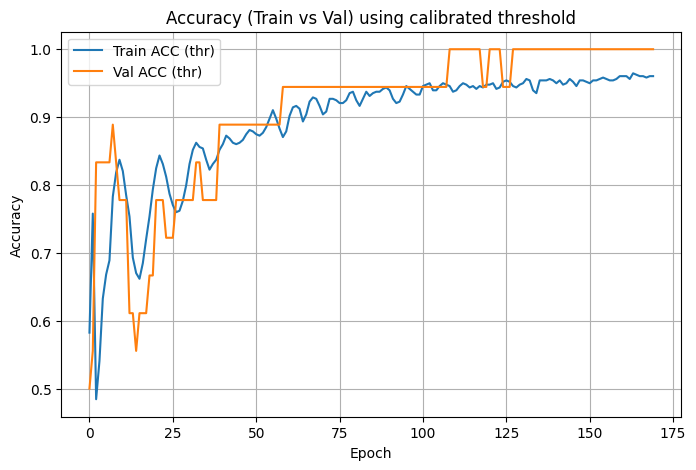

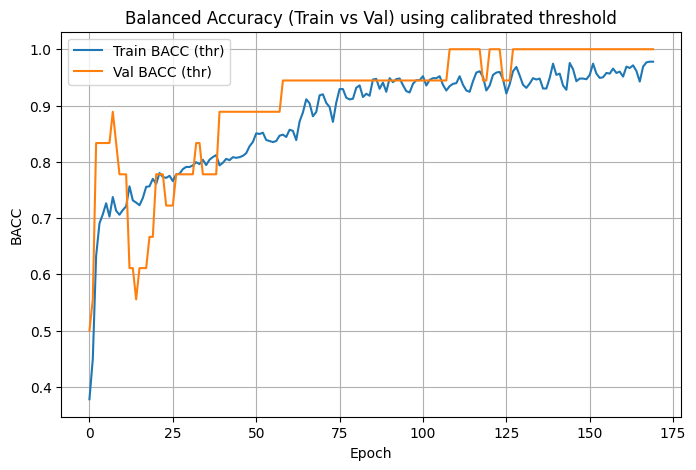

FINAL TEST EVALUATION (Current config + calibrated threshold)
Threshold used: 0.484970
Test Accuracy: 0.8750
Test Balanced Accuracy: 0.7428
Test ROC-AUC: 0.8281
Confusion Matrix (Counts) [[TN FP],[FN TP]]:
[[ 9  7]
 [ 8 96]]
Recall class 0 (specificity): 0.5625
Recall class 1 (sensitivity): 0.9231
Classification report:
                  precision    recall  f1-score   support

Non-survivor (0)     0.5294    0.5625    0.5455        16
    Survivor (1)     0.9320    0.9231    0.9275       104

        accuracy                         0.8750       120
       macro avg     0.7307    0.7428    0.7365       120
    weighted avg     0.8784    0.8750    0.8766       120



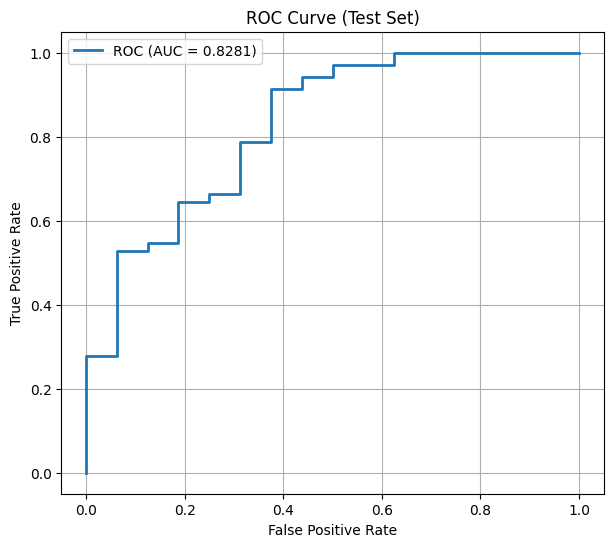

In [5]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


BEST = {
    "hidden_dim": 128,
    "num_layers": 2,
    "dropout_p": 0.1,
    "lr": 0.0005013165451552093,
    "weight_decay": 3.8275975620529385e-06,
    "num_epochs": 170,
    "k_neighbors": 20,
    "knn_metric": "cosine",
    "knn_symmetric": True,
    "focal_gamma": 5.0,
}

BEST_THRESHOLD = 0.4849699398797595


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        pt = probs.gather(1, target.view(-1, 1)).squeeze(1)
        log_pt = log_probs.gather(1, target.view(-1, 1)).squeeze(1)

        loss = -((1.0 - pt) ** self.gamma) * log_pt

        if self.alpha is not None:
            at = self.alpha.gather(0, target)
            loss = loss * at

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


class RelationalGNN(nn.Module):
    def __init__(
        self,
        in_img: int,
        in_pat: int,
        hidden_dim: int,
        dropout_p: float,
        num_classes: int,
        num_relations: int,
        num_layers: int,
    ):
        super().__init__()

        self.lin_img = nn.Linear(in_img, hidden_dim)
        self.lin_pat = nn.Linear(in_pat, hidden_dim)

        self.convs = nn.ModuleList(
            [RGCNConv(hidden_dim, hidden_dim, num_relations) for _ in range(num_layers)]
        )

        self.dropout = nn.Dropout(dropout_p)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_p),
        )

        self.out = nn.Linear(hidden_dim, num_classes)

    def forward(
        self,
        x_img: torch.Tensor,
        x_pat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_type: torch.Tensor,
    ) -> torch.Tensor:
        h_img = F.gelu(self.lin_img(x_img))
        h_pat = F.gelu(self.lin_pat(x_pat))
        h = torch.cat([h_img, h_pat], dim=0)

        for conv in self.convs:
            h = F.gelu(conv(h, edge_index, edge_type))
            h = self.dropout(h)

        h = self.mlp(h)
        return self.out(h)


def focal_alpha_from_mask(y_pat: torch.Tensor, mask: torch.Tensor, dev) -> torch.Tensor:
    y_np = y_pat[mask].detach().cpu().numpy()
    n0 = int((y_np == 0).sum())
    n1 = int((y_np == 1).sum())
    n = n0 + n1
    a0 = n / (2 * max(n0, 1))
    a1 = n / (2 * max(n1, 1))
    return torch.tensor([a0, a1], dtype=torch.float, device=dev)


def build_fixed_ip_edges(data, n_img: int, dev):
    edge_indices = []
    edge_types = []

    ei = data["image", "to", "patient"].edge_index.to(dev)
    edge_indices.append(torch.vstack([ei[0], ei[1] + n_img]))
    edge_types.append(torch.zeros(ei.size(1), dtype=torch.long, device=dev))

    ei = data["patient", "rev", "image"].edge_index.to(dev)
    edge_indices.append(torch.vstack([ei[0] + n_img, ei[1]]))
    edge_types.append(torch.ones(ei.size(1), dtype=torch.long, device=dev))

    return edge_indices, edge_types


def build_knn_patient_edges_fit_on_subset(
    x_pat: torch.Tensor,
    n_img: int,
    fit_idx,
    k: int,
    metric: str = "cosine",
    symmetric: bool = True,
    dev=None,
):
    x_pat_cpu = x_pat.detach().cpu().numpy().astype(np.float32)
    fit_idx = np.array(fit_idx, dtype=np.int64)

    if metric not in {"cosine", "euclidean"}:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    nn_model = NearestNeighbors(n_neighbors=min(k, len(fit_idx)), metric=metric)
    nn_model.fit(x_pat_cpu[fit_idx])

    _, nn_pos = nn_model.kneighbors(x_pat_cpu)

    src, dst = [], []
    n_pat = x_pat_cpu.shape[0]

    for i in range(n_pat):
        neigh = fit_idx[nn_pos[i]].tolist()
        if i in neigh:
            neigh.remove(i)
        neigh = neigh[:k]
        for j in neigh:
            src.append(i)
            dst.append(j)

    if symmetric:
        src2 = dst
        dst2 = src
        src = src + src2
        dst = dst + dst2

    src = torch.tensor(src, dtype=torch.long, device=dev)
    dst = torch.tensor(dst, dtype=torch.long, device=dev)

    edge_index_pp = torch.vstack([src + n_img, dst + n_img])
    edge_type_pp = torch.full((edge_index_pp.size(1),), 2, dtype=torch.long, device=dev)

    return edge_index_pp, edge_type_pp


@torch.no_grad()
def eval_complete_test(
    model: nn.Module,
    x_img: torch.Tensor,
    x_pat: torch.Tensor,
    y_pat: torch.Tensor,
    edge_index: torch.Tensor,
    edge_type: torch.Tensor,
    n_img: int,
    test_pat_mask: torch.Tensor,
    threshold: float,
):
    model.eval()
    out = model(x_img, x_pat, edge_index, edge_type)

    mask_test_global = torch.cat(
        [torch.zeros(n_img, dtype=torch.bool, device=x_img.device), test_pat_mask]
    )
    logits = out[mask_test_global]

    prob1 = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    y_true = y_pat[test_pat_mask].detach().cpu().numpy()
    y_pred = (prob1 >= threshold).astype(int)

    acc = float(accuracy_score(y_true, y_pred))
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    auc_val = float(roc_auc_score(y_true, prob1)) if len(np.unique(y_true)) > 1 else float("nan")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Non-survivor (0)", "Survivor (1)"],
        zero_division=0,
        digits=4,
    )

    fpr, tpr, _ = roc_curve(y_true, prob1)
    roc_auc_plot = auc(fpr, tpr)

    tn, fp, fn, tp = cm.ravel()
    recall_0 = tn / (tn + fp + 1e-12)
    recall_1 = tp / (tp + fn + 1e-12)

    return {
        "threshold": float(threshold),
        "acc": acc,
        "bacc": bacc,
        "auc": auc_val,
        "cm": cm,
        "report": report,
        "recall_0": float(recall_0),
        "recall_1": float(recall_1),
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc_plot": float(roc_auc_plot),
        "prob1": prob1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


data = data.to(device)

x_img = data["image"].x.to(device)
x_pat = data["patient"].x.to(device)
y_pat = data["patient"].y.to(device)

train_mask = data["patient"].train_mask.to(device)
val_mask = data["patient"].val_mask.to(device)
test_mask = data["patient"].test_mask.to(device)

N_img = data["image"].num_nodes
in_img = x_img.shape[1]
in_pat = x_pat.shape[1]
num_classes = 2


fixed_edge_indices, fixed_edge_types = build_fixed_ip_edges(data, N_img, device)

tv_mask_np = (train_mask | val_mask).detach().cpu().numpy().astype(bool)
tv_idx = np.where(tv_mask_np)[0]

edge_index_pp, edge_type_pp = build_knn_patient_edges_fit_on_subset(
    x_pat=x_pat,
    n_img=N_img,
    fit_idx=tv_idx,
    k=BEST["k_neighbors"],
    metric=BEST["knn_metric"],
    symmetric=BEST["knn_symmetric"],
    dev=device,
)

edge_index = torch.cat([*fixed_edge_indices, edge_index_pp], dim=1)
edge_type = torch.cat([*fixed_edge_types, edge_type_pp], dim=0)


train_final_mask = train_mask | val_mask
monitor_train_mask = train_mask
monitor_val_mask = val_mask

mask_train_global_final = torch.cat(
    [torch.zeros(N_img, dtype=torch.bool, device=device), train_final_mask]
)
mask_train_global_monitor = torch.cat(
    [torch.zeros(N_img, dtype=torch.bool, device=device), monitor_train_mask]
)
mask_val_global_monitor = torch.cat(
    [torch.zeros(N_img, dtype=torch.bool, device=device), monitor_val_mask]
)


set_seed(42)

model = RelationalGNN(
    in_img=in_img,
    in_pat=in_pat,
    hidden_dim=BEST["hidden_dim"],
    dropout_p=BEST["dropout_p"],
    num_classes=num_classes,
    num_relations=3,
    num_layers=BEST["num_layers"],
).to(device)

alpha = focal_alpha_from_mask(y_pat, train_mask, dev=device)
loss_fn = FocalLoss(gamma=BEST["focal_gamma"], alpha=alpha, reduction="mean")

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=BEST["lr"],
    weight_decay=BEST["weight_decay"],
)

print("Training FINAL model on (train+val), monitoring train vs val")
print("Config:", BEST)
print(f"Calibrated threshold used for monitoring/test: {BEST_THRESHOLD:.6f}")


hist = {
    "train_loss": [],
    "train_acc": [],
    "train_bacc": [],
    "val_loss": [],
    "val_acc": [],
    "val_bacc": [],
}

for epoch in range(1, BEST["num_epochs"] + 1):
    model.train()
    optimizer.zero_grad()

    out = model(x_img, x_pat, edge_index, edge_type)
    logits_train_final = out[mask_train_global_final]

    loss = loss_fn(logits_train_final, y_pat[train_final_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_eval = model(x_img, x_pat, edge_index, edge_type)

        log_tr = out_eval[mask_train_global_monitor]
        y_tr = y_pat[monitor_train_mask]
        tr_loss = float(loss_fn(log_tr, y_tr).item())

        prob_tr = torch.softmax(log_tr, dim=1)[:, 1].detach().cpu().numpy()
        y_tr_np = y_tr.detach().cpu().numpy()
        pred_tr = (prob_tr >= BEST_THRESHOLD).astype(int)
        tr_acc = float(accuracy_score(y_tr_np, pred_tr))
        tr_bacc = float(balanced_accuracy_score(y_tr_np, pred_tr))

        log_va = out_eval[mask_val_global_monitor]
        y_va = y_pat[monitor_val_mask]
        va_loss = float(loss_fn(log_va, y_va).item())

        prob_va = torch.softmax(log_va, dim=1)[:, 1].detach().cpu().numpy()
        y_va_np = y_va.detach().cpu().numpy()
        pred_va = (prob_va >= BEST_THRESHOLD).astype(int)
        va_acc = float(accuracy_score(y_va_np, pred_va))
        va_bacc = float(balanced_accuracy_score(y_va_np, pred_va))

    hist["train_loss"].append(tr_loss)
    hist["train_acc"].append(tr_acc)
    hist["train_bacc"].append(tr_bacc)
    hist["val_loss"].append(va_loss)
    hist["val_acc"].append(va_acc)
    hist["val_bacc"].append(va_bacc)

    if epoch % 10 == 0 or epoch == 1 or epoch == BEST["num_epochs"]:
        print(
            f"Epoch {epoch:03d}/{BEST['num_epochs']} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} train_bacc={tr_bacc:.4f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.4f} val_bacc={va_bacc:.4f}"
        )


plt.figure(figsize=(8, 5))
plt.plot(hist["train_loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.title("Loss (Train vs Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["train_acc"], label="Train ACC (thr)")
plt.plot(hist["val_acc"], label="Val ACC (thr)")
plt.title("Accuracy (Train vs Val) using calibrated threshold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["train_bacc"], label="Train BACC (thr)")
plt.plot(hist["val_bacc"], label="Val BACC (thr)")
plt.title("Balanced Accuracy (Train vs Val) using calibrated threshold")
plt.xlabel("Epoch")
plt.ylabel("BACC")
plt.grid(True)
plt.legend()
plt.show()


test_res = eval_complete_test(
    model=model,
    x_img=x_img,
    x_pat=x_pat,
    y_pat=y_pat,
    edge_index=edge_index,
    edge_type=edge_type,
    n_img=N_img,
    test_pat_mask=test_mask,
    threshold=BEST_THRESHOLD,
)

print("FINAL TEST EVALUATION (Current config + calibrated threshold)")
print(f"Threshold used: {test_res['threshold']:.6f}")
print(f"Test Accuracy: {test_res['acc']:.4f}")
print(f"Test Balanced Accuracy: {test_res['bacc']:.4f}")
print(f"Test ROC-AUC: {test_res['auc']:.4f}")

print("Confusion Matrix (Counts) [[TN FP],[FN TP]]:")
print(test_res["cm"])

print(f"Recall class 0 (specificity): {test_res['recall_0']:.4f}")
print(f"Recall class 1 (sensitivity): {test_res['recall_1']:.4f}")

print("Classification report:")
print(test_res["report"])

plt.figure(figsize=(7, 6))
plt.plot(
    test_res["fpr"],
    test_res["tpr"],
    linewidth=2,
    label=f"ROC (AUC = {test_res['roc_auc_plot']:.4f})",
)
plt.title("ROC Curve (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()
